In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cooler
import bioframe
import cooltools
from cooltools.lib import plotting
import cooler as clr
import h5py
import coolbox
from coolbox.api import *
from coolbox.utilities import GenomeRange
from pygenometracks import readBed, readGtf
from pygenometracks.tracks import BedTrack

import glob
from pathlib import Path


%cd /home/varshini/uc_analyses/
import utils, coolbox_helpers
%cd /home/varshini/LoopCall_Analysis_Scripts
import re

warnings.filterwarnings("ignore")

import logging
logging.getLogger('matplotlib.font_manager').disabled = True
from matplotlib.backends.backend_pdf import PdfPages

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12

plt.rcParams.update({
    "text.usetex": False})
plt.rc('pdf',fonttype = 42)

In [3]:
def make_region_plot_mod(region, resolution, microc_file,
                     bw_list, condition_order, gene_annot_name, bedgraph_fname=None, plot_variants=False,
                     file_bottom=None, cmap_chip='tab10', bigwig_bins=1600, autoscale=True, plot_bed=False,
                        variant_track_height=2, custom_valranges=None, plot_genes=True):
    
    """
    Function that makes a plot of a region with Micro-C, ChIP-seq, and Pro-seq.
    
    region: (str) string that specifies region for plotting.
    resolution: (int) resolution of micro-c map used
    highlight_region_list: List of regions of format [chr, start, end] to highlight
    microc_file: (str) file path to micro-c data
    microc_title: (str) title for micro-c
    chip_list_list: List of lists containing paths to bigwigs
    forward_proseq_list: List of paths to forward strand pro-seq files
    reverse_proseq_list: List of paths to reverse strand pro-seq files
    condition_order: List indicating order of conditions to plot. 
    """
    print(region, resolution, microc_file)
    heatmap = Cool(microc_file, file_bottom=file_bottom, resolution=resolution, **MICROC_PLOTTING_PARAMS) 
    frame = heatmap + Spacer(SPACER_HEIGHT*3)
    if plot_bed:
        frame+=NewBed(*BED_PARAMS) + TrackHeight(3) + Spacer(SPACER_HEIGHT)
    #frame +=  BED(finemapped_variant_name, border_only=True, 
    #              alpha=0.1, show_score='yes', linewidth=0.5, display="collapsed", height=1, edgecolor="#0099BB") + Spacer(SPACER_HEIGHT)
    if len(bw_list)>0:
        bigwig_list = coolbox_helpers.make_bigwig_list(bw_list, region, condition_order, autoscale=False)
        cmap_arr = sns.color_palette(cmap_chip, n_colors=len(bigwig_list))

        for i, bigwig in enumerate(bigwig_list):
            if autoscale:
                frame += coolbox_helpers.auto_scale_bigwig(bigwig, region) + Color(cmap_arr[i]) + Spacer(SPACER_HEIGHT)
            else:
                frame += bigwig + MaxValue(custom_valranges[i]) + MinValue(0) + Color(cmap_arr[i]) + Spacer(SPACER_HEIGHT)

    if bedgraph_fname is not None:
        frame += BigWig(bedgraph_fname) + Title("HbF_Base") + Color("#EE7733") + MaxValue(30) + MinValue(0)+ Spacer(SPACER_HEIGHT)
    
    if plot_variants:
        frame+=SNP(finemapped_variant_name, **VARIANTS_PARAMS) \
        + HLines(0, line_width=2, line_style='-',color='k') + Title("HbF GWAS [-log10(p)]")  + TrackHeight(variant_track_height) + Spacer(SPACER_HEIGHT)
    
    if plot_genes:
        annotations = NewBed(*GTF_PARAMS)
#     annotations = GTF(gene_annot_name, color=["#000000"], gene_rows=1, 
#                       filter_named_genes=True, row_filter=None) 
    frame+=annotations

    return frame


def multiplot(mcool1, mcool2, peaks, resolution=5000):
    for index, row in peaks.iterrows():
        plt.figure()
        region_str = get_locus_from_coord(row, flank=200_000)

        # Reverse these
        microc_file1 = mcool1
        microc_file2 = mcool2
        microc_title = f"{region_str} at {resolution}"
        heatmap = Cool(microc_file1, file_bottom=microc_file2,
                       resolution=resolution, **MICROC_PLOTTING_PARAMS) + Title(microc_title)
        frame = heatmap
        annotations = NewBed(*ANNOTATIONS_PARAMS)
        frame += annotations
        frame += XAxis()
        fig = frame.plot(region_str)



In [4]:
class ChromName(Track):
    """
    Track for show chromosome name.

    Parameters
    ----------
    fontsize : float
        Font name to show.

    offset : float
        Offset ratio to the start position.
    """

    DEFAULT_PROPERTIES = {
        "fontsize": 50,
        "offset": 0.45,
    }

    def __init__(self, **kwargs):
        properties = ChromName.DEFAULT_PROPERTIES.copy()
        properties.update(kwargs)
        super().__init__(properties)

    def fetch_data(self, gr: GenomeRange, **kwargs):
        return gr.chrom  # return chromosome name

    def plot(self, ax, gr: GenomeRange, **kwargs):
        x = gr.start + self.properties['offset'] * (gr.end - gr.start)
        ax.text(x, 0, gr.chrom, fontsize=self.properties['fontsize'])
        ax.set_xlim(gr.start, gr.end)


class NewBed(Track):
    """
    Custom pygenometracks class that allows for control over the aesthetics of gene annotations in
    region plots.
    """

    def __init__(self, coolbox_prop_dict, pygenometracks_prop_dict):
        super().__init__(coolbox_prop_dict)  # init
        self.pygenometracks_object = BedTrack(pygenometracks_prop_dict)

    def fetch_data(self, gr, **kwargs):
        pass

    def plot(self, ax, gr, **kwargs):
        #         x = gr.start + self.properties['offset'] * (gr.end - gr.start)
        #         ax.text(x, 0, gr.chrom, fontsize=self.properties['fontsize'])
        #         ax.set_xlim(gr.start, gr.end)
        self.pygenometracks_object.plot(ax, gr.chrom, gr.start, gr.end)
        ax.set_xlim([gr.start, gr.end])

In [5]:
# define the bigwig and RNAseq files 
base_dir = '/mnt/coldstorage/Varshmallow/'

def get_chip_list(base_dir='/mnt/coldstorage/Varshmallow/', phase=1, phase2=None, 
                  include=['RNASeq', 'ATAC', 'H3K27ac', 'H3K4me1']):

    chip_dict = {}
    chip_dict[f'RNASeq_P{phase}'] = f'{base_dir}Blood_RNAseq/Phase{phase}_RNA_chr.bw'
    
    # ATAC-Seq
    chip_dict[f'ATAC_P{phase}'] = f'{base_dir}Blood_ATAC/Phase{phase}_ATAC.bw'
    
    chip_dict['NIPBL'] = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/bigwigs/GSM8864683_HUDEP-2_NIPBL_rep1_2_mean.bw'
 
    # GATA-1 
    
    
    if phase2 is not None:
        chip_dict[f'ATAC_P{phase2}'] = f'{base_dir}Blood_ATAC/Phase{phase2}_ATAC.bw'
        chip_dict[f'RNASeq_P{phase2}'] = f'{base_dir}Blood_RNAseq/Phase{phase2}_RNA_chr.bw'
        
    # Histone ChIP
    chip_dir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/bigwigs/'

    directory = os.fsencode(chip_dir)
    
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        rm = re.match(rf'\w*P{phase}_CTCF\S*', filename)
        if rm is not None:
            chip_dict[f'CTCF_P{phase}'] = f'{chip_dir}{rm.group(0)}'

        rm = re.match(rf'\w*P{phase}_H3K27ac\S*', filename)
        if rm is not None:
            chip_dict[f'H3K27ac_P{phase}']  = f'{chip_dir}{rm.group(0)}'

        rm = re.match(rf'\w*P{phase}_H3K4me1\S*', filename)
        if rm is not None:
            chip_dict[f'H3K4me1_P{phase}'] = f'{chip_dir}{rm.group(0)}'
       
        rm = re.match(r'\w*GATA1\S*', filename)
        if rm is not None:
            chip_dict[f'GATA1'] = f'{base_dir}Blood_ChIP/P{phase}/{rm.group(0)}'
            
        
    if phase2 is not None:
        for file in os.listdir(directory):
            filename = os.fsdecode(file)
            rm = re.match(rf'\w*P{phase2}_CTCF\S*', filename)
            if rm is not None:
                chip_dict[f'CTCF_P{phase2}'] = f'{chip_dir}{rm.group(0)}'

            rm = re.match(rf'\w*P{phase2}_H3K27ac\S*', filename)
            if rm is not None:
                chip_dict[f'H3K27ac_P{phase2}']  = f'{chip_dir}{rm.group(0)}'

            rm = re.match(rf'\w*P{phase2}_H3K4me1\S*', filename)
            if rm is not None:
                chip_dict[f'H3K4me1_P{phase2}'] = f'{chip_dir}{rm.group(0)}'

        
    chip_list = [chip_dict[key] for key in include]
    return chip_list


In [6]:
resolution = 2000
phases_microc = {1: 'Phase1_', 2:'Phase2_dedup',3:'Phase3_dedup'}

phases = ['Phase1_', 'Phase2_dedup', 'Phase3_dedup']
uc_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
uc_filenames = [os.path.join(uc_path, f"Sankaran_{p}merged.250.mcool") for p in phases]



In [7]:
GTF_FILENAME = "/mnt/md0/varshini/Gene_Annotations/refSeqSelect.bed"
GRNA = '/mnt/md0/varshini/Analysis/Blood/Tracks_Intersection_Analysis_NewCTCF/hbf_grna.bw'
finemapped_variant_name = '/mnt/md0/varshini/Analysis/Blood/hbf_gwas/METALOUT_inv1.bed'

# Define plotting aesthetics as global variables
HIGHLIGHT_PARAMS = {"color":"gray",
                   "alpha":0.5,
                   "border_line":False}

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-0.5,
                          "min_value":-4.5}

VARIANTS_PARAMS = {
    "col_chrom":0, 
    "col_pos":2,
    "col_pval":6, 
    "threshold":10e-8, 
    "min_value":0, 
    "size":20,
    "alpha":0.75}

SPACER_HEIGHT = 0.4

regions = {
        'BCL11A':'chr2:59964475-60946280',
        'BCL11A_loop':'chr2:60474501-60570501',
        'BCL11A_full':'chr2:58464475-60946280',
        'loop_appear': 'chr5:173570169-174026097 ',
        'loop_disappear': 'chr7:11365292-12545212',
        'boundary_appear_2': 'chr14:101120681-104109207',
        'boundary_disappear': 'chr8:75561811-79081548',
        'compt_ex1': 'chr5:149023111-152003168',
        #'compt_ex2': 'chr1:50000000–100000000',
        'compt_ex2': 'chr1:48000000-102000000',
}




## Figure 1

In [9]:
savedir = os.path.join('/mnt/md0/varshini/Analysis/Blood/figs_v4/fig1')
os.mkdir(savedir)

chr5:149023111-152003168 10000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|████████████████████████████████████| 22438/22438 [00:00<00:00, 27893.89it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 17.18,-0.08


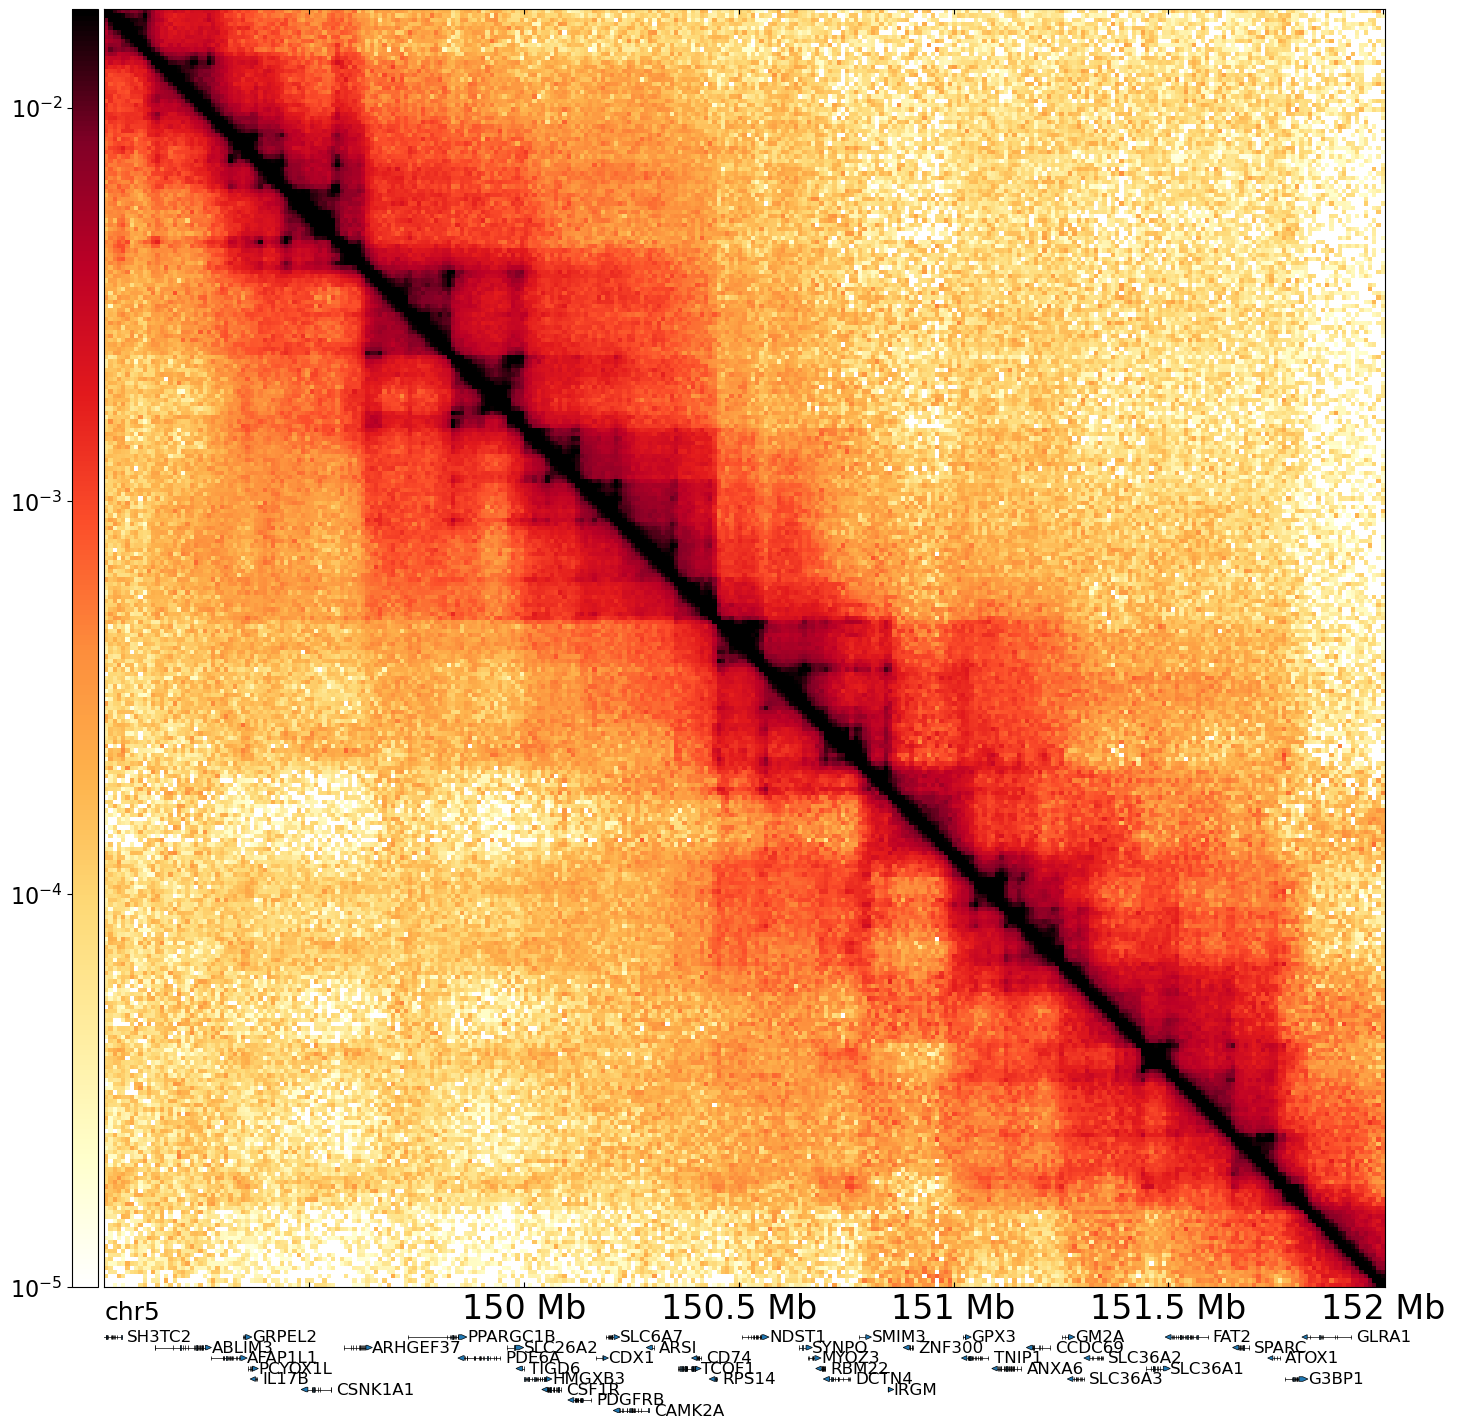

In [11]:
# Figure 1B compartment

region_str = regions["compt_ex1"]
resolution=10000

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-1.75,
                          "min_value":-5,
                         "fontsize":18}


GTF_PARAMS = [
     {"height":2},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    #"gene_rows":1,
    "merge_transcripts":True,       #"gene_style":"normal",
    "border_only":"true"
    }] # PATH TO BED FILE OF GENE ANNOTATIONS

incl= []

chip_list = get_chip_list(include=incl, phase=1, phase2=3)

frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=None,
                         bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True, plot_bed=False)
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "compt_ex1.svg"))
fig

chr8:75561811-79081548 10000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|████████████████████████████████████| 22438/22438 [00:00<00:00, 25756.32it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 5.68,-0.08


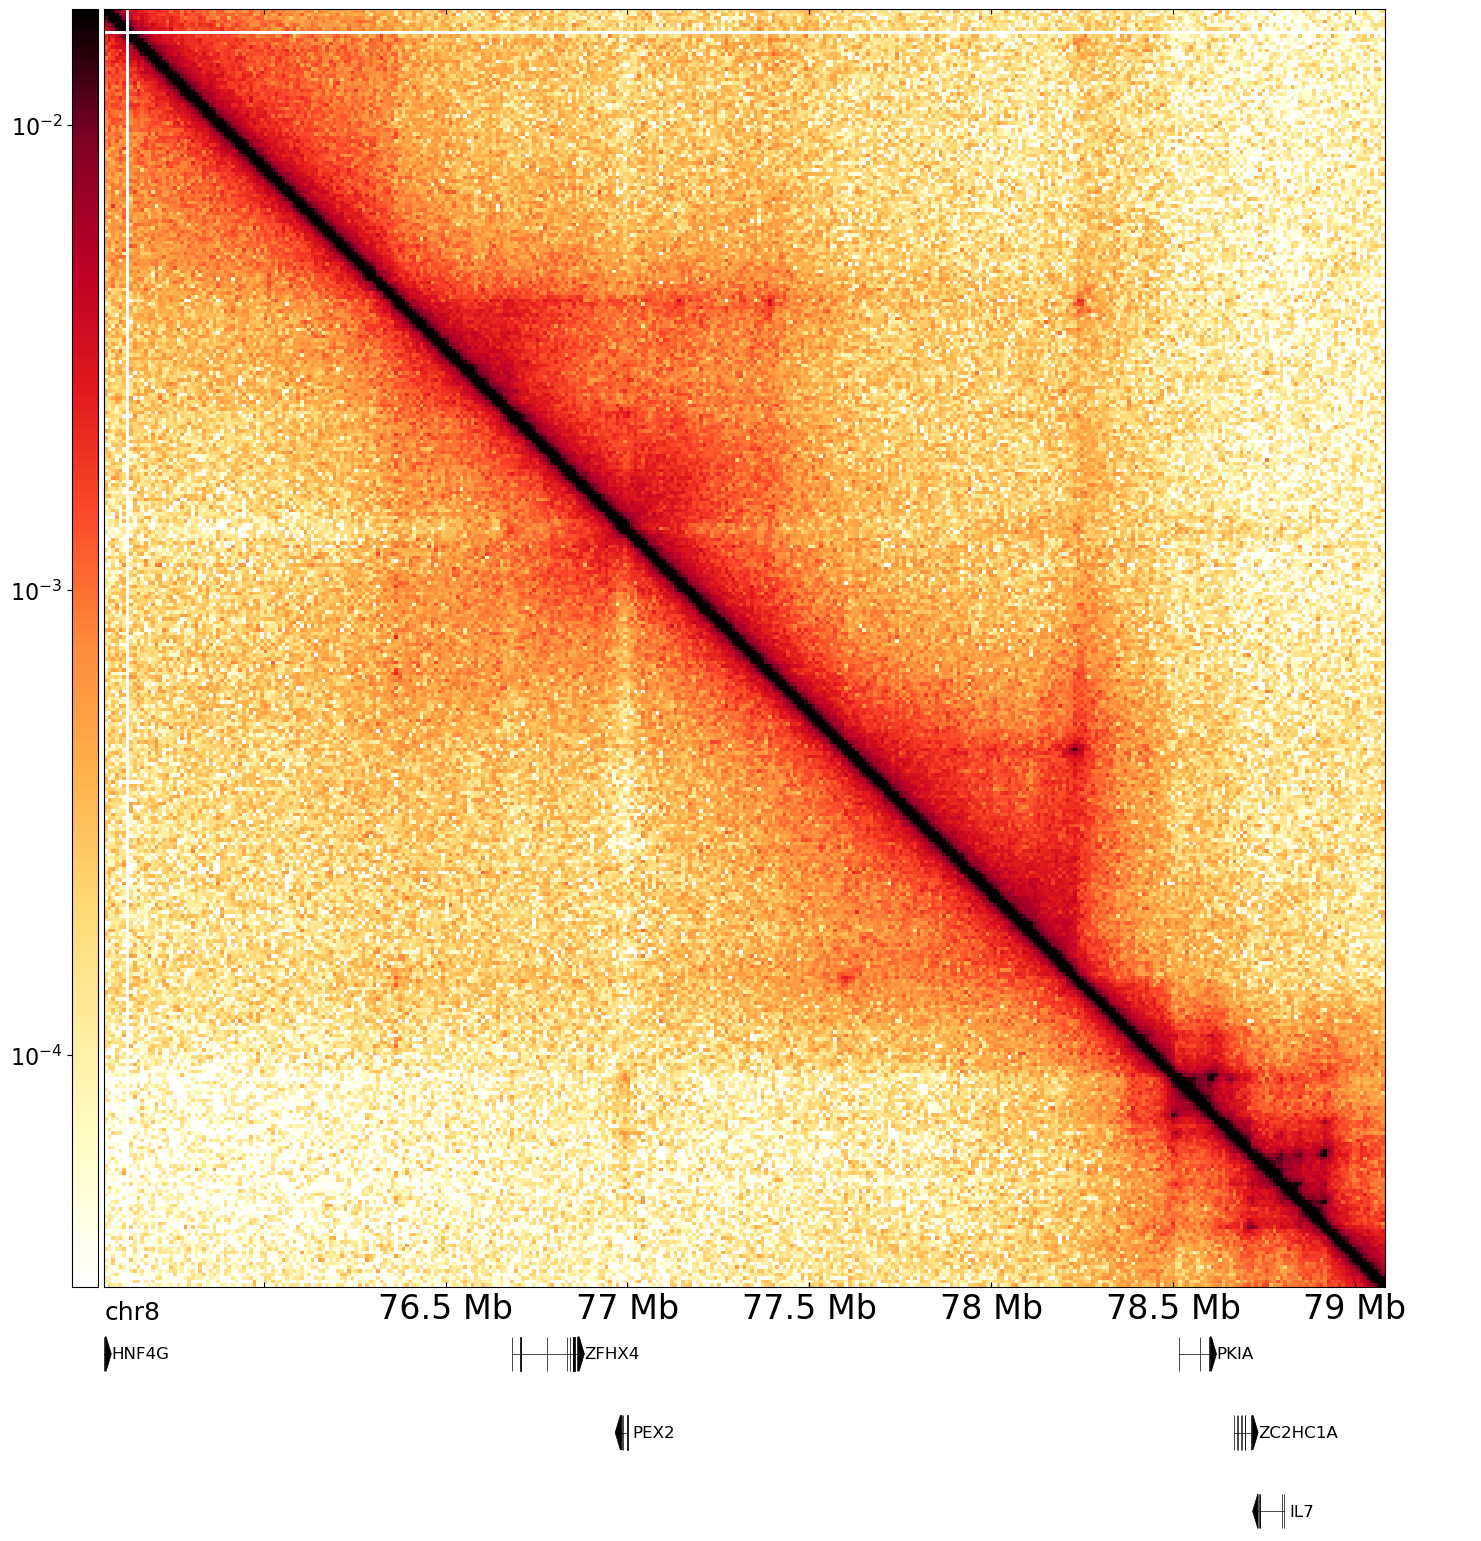

In [12]:
# Figure 1B boundary

region_str = regions["boundary_disappear"]
resolution=10000

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-1.75,
                          "min_value":-4.5,
                         "fontsize":18}


GTF_PARAMS = [
     {"height":5},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    #"gene_rows":3,
    "merge_transcripts":True,       #"gene_style":"normal",
    "border_only":"true",
     "color":"#000000"
    }] # PATH TO BED FILE OF GENE ANNOTATIONS

incl= []

chip_list = get_chip_list(include=incl, phase=1, phase2=3)

frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True, plot_bed=False)
fig = frame.plot(region_str)

fig.savefig(os.path.join(savedir, "boundary_disappear.svg"))
fig

In [17]:
# Figure 1C

region_str = regions["BCL11A_full"]
incl=["CTCF_P3", "ATAC_P3"]
resolution=5000

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-1.5,
                          "min_value":-4.5,
                         "fontsize":18}

GTF_PARAMS = [
     {"height":5},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    "gene_rows":3,
    "merge_transcripts":True,    
    "border_only":"true",
     "color":"#000000"
    }] 

ANNOTATIONS_PARAMS = [{"height":5},
                      {"file": finemapped_variant_name,
                      "max_labels":1,
                      "gene_rows":1,
                      #"gene_style":"normal",
                      "border_only":"true"}] # PATH TO BED FILE OF GENE ANNOTATIONS

chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=GRNA, plot_variants=True, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True, plot_genes=True,
                             plot_bed=False)
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "BCL11A.svg"))

chr2:58464475-60946280 5000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|████████████████████████████████████| 22438/22438 [00:01<00:00, 19272.69it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 7.9799999999999995,-0.08


chr19:49314500-49733500 1000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|████████████████████████████████████| 22438/22438 [00:01<00:00, 17732.55it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 10.28,-0.08


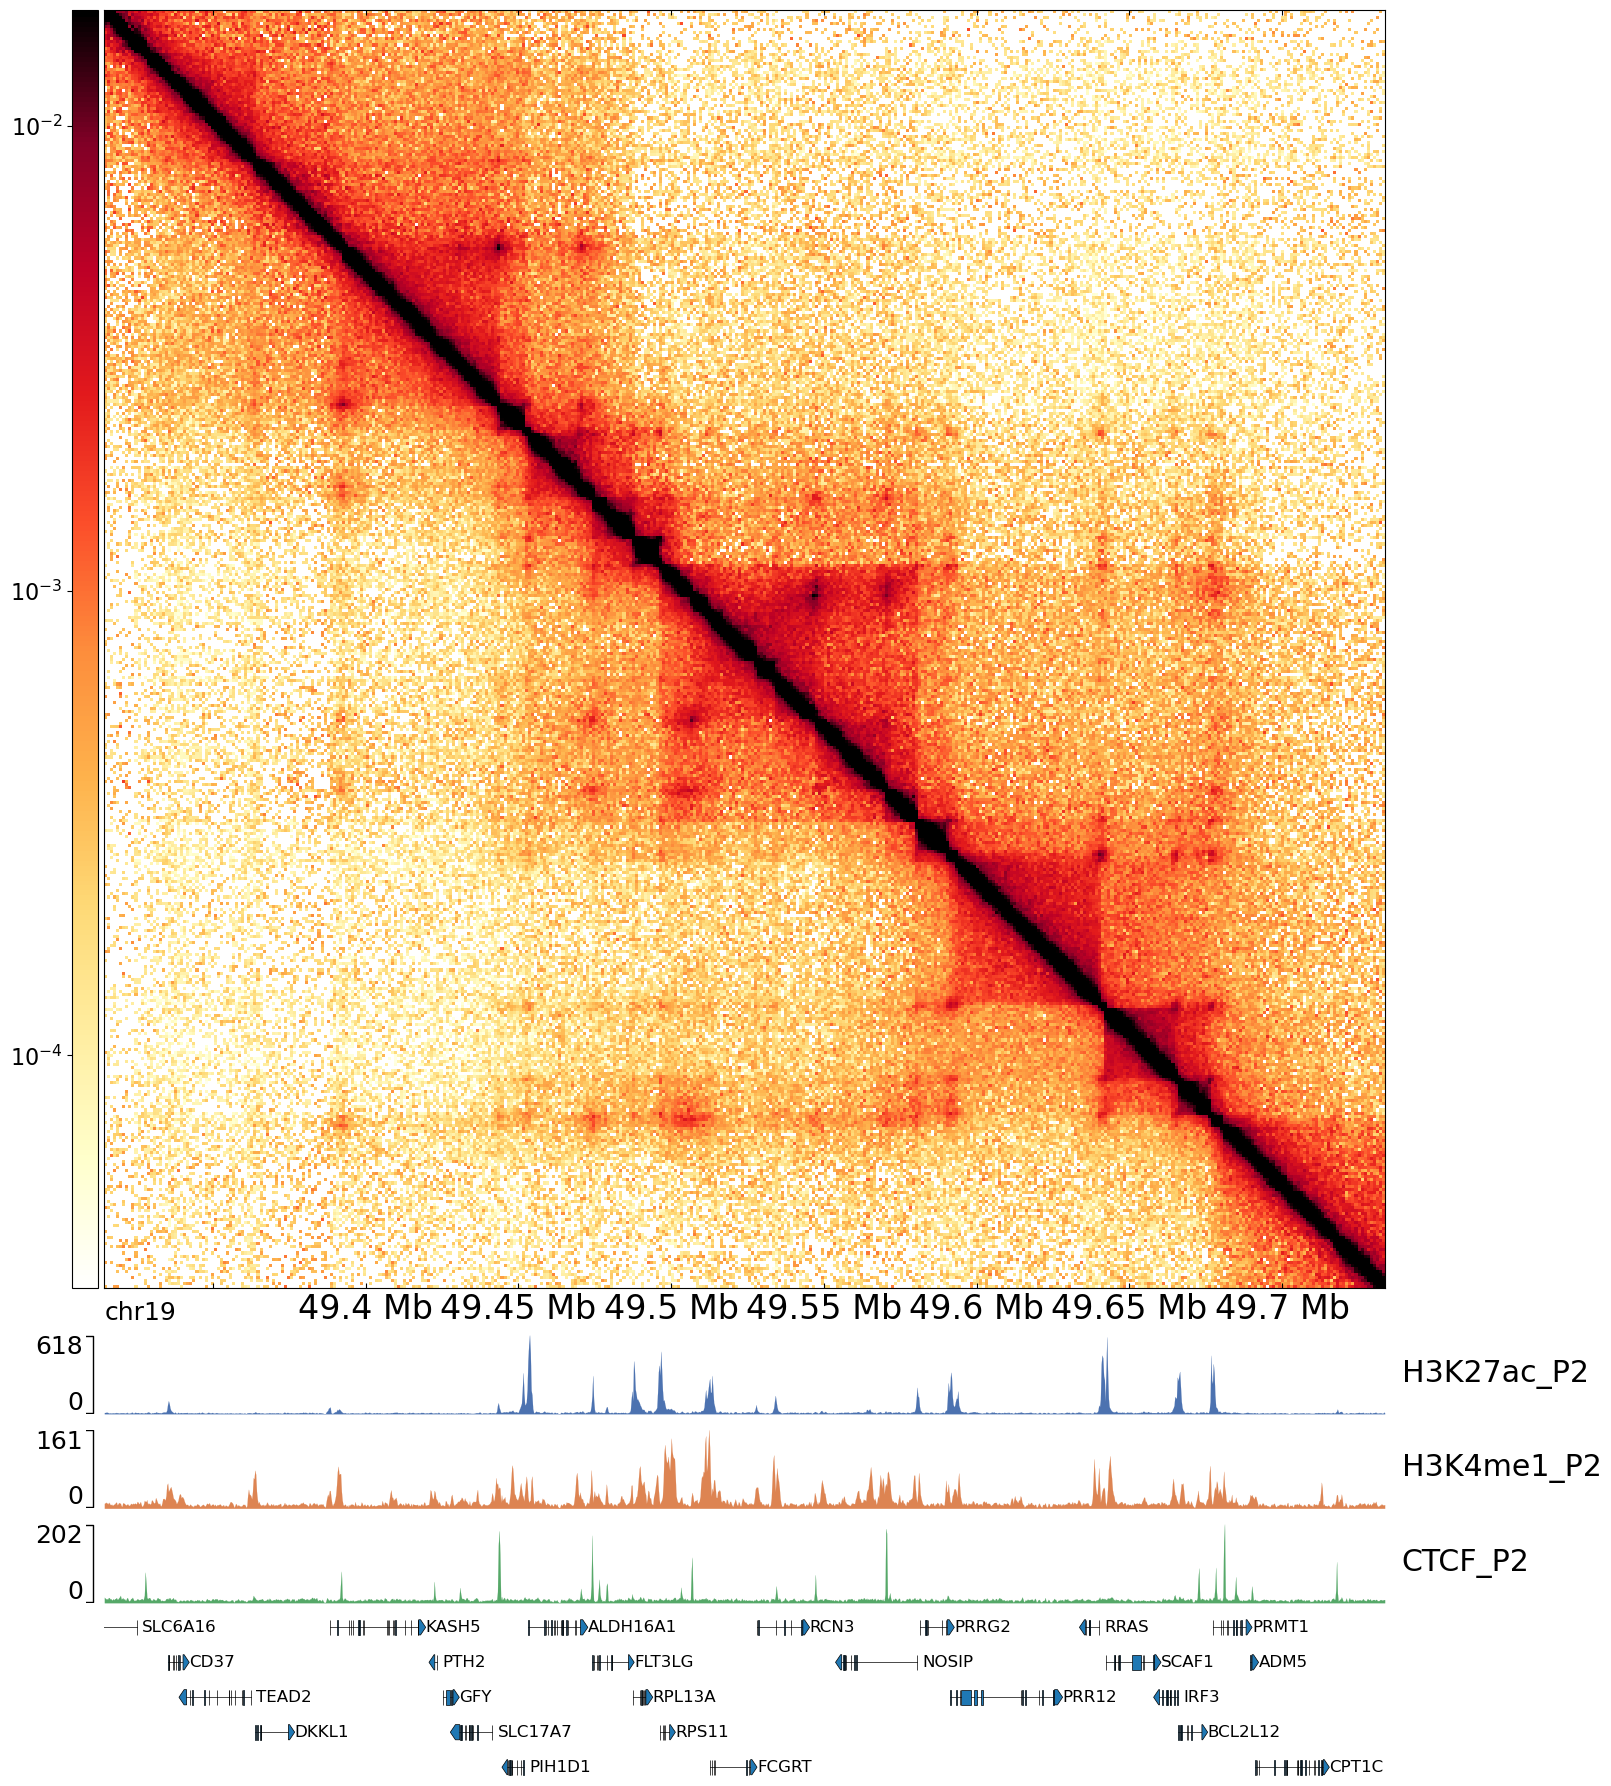

In [19]:
# Figure 1D

region_str = 'chr19:49314500-49733500'

resolution=1000

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-1.75,
                          "min_value":-4.5,
                         "fontsize":18}


GTF_PARAMS = [
     {"height":4},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    #"gene_rows":1,
    "merge_transcripts":True,       #"gene_style":"normal",
    "border_only":"true"
    }] # PATH TO BED FILE OF GENE ANNOTATIONS

tf_acrs_name = '/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/erythroid_tf_acrs_unique.bed'
BED_PARAMS = [{"height":1},
                      {"file": tf_acrs_name,
                      "max_labels":1,
                       "gene_rows":1,
                      "border_only":"true"}]


incl= ['H3K27ac_P2','H3K4me1_P2', 'CTCF_P2']

chip_list = get_chip_list(include=incl, phase=2, phase2=1)

frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True,plot_genes=True, 
                             plot_bed=False)
fig = frame.plot(region_str)
fig
#fig.savefig(os.path.join(savedir, "changing_cre_ctcf_ex.svg"))

## Figure 2

chr8:23,458,956-23,585,463 1000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33179.55it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 7.9799999999999995,-0.08


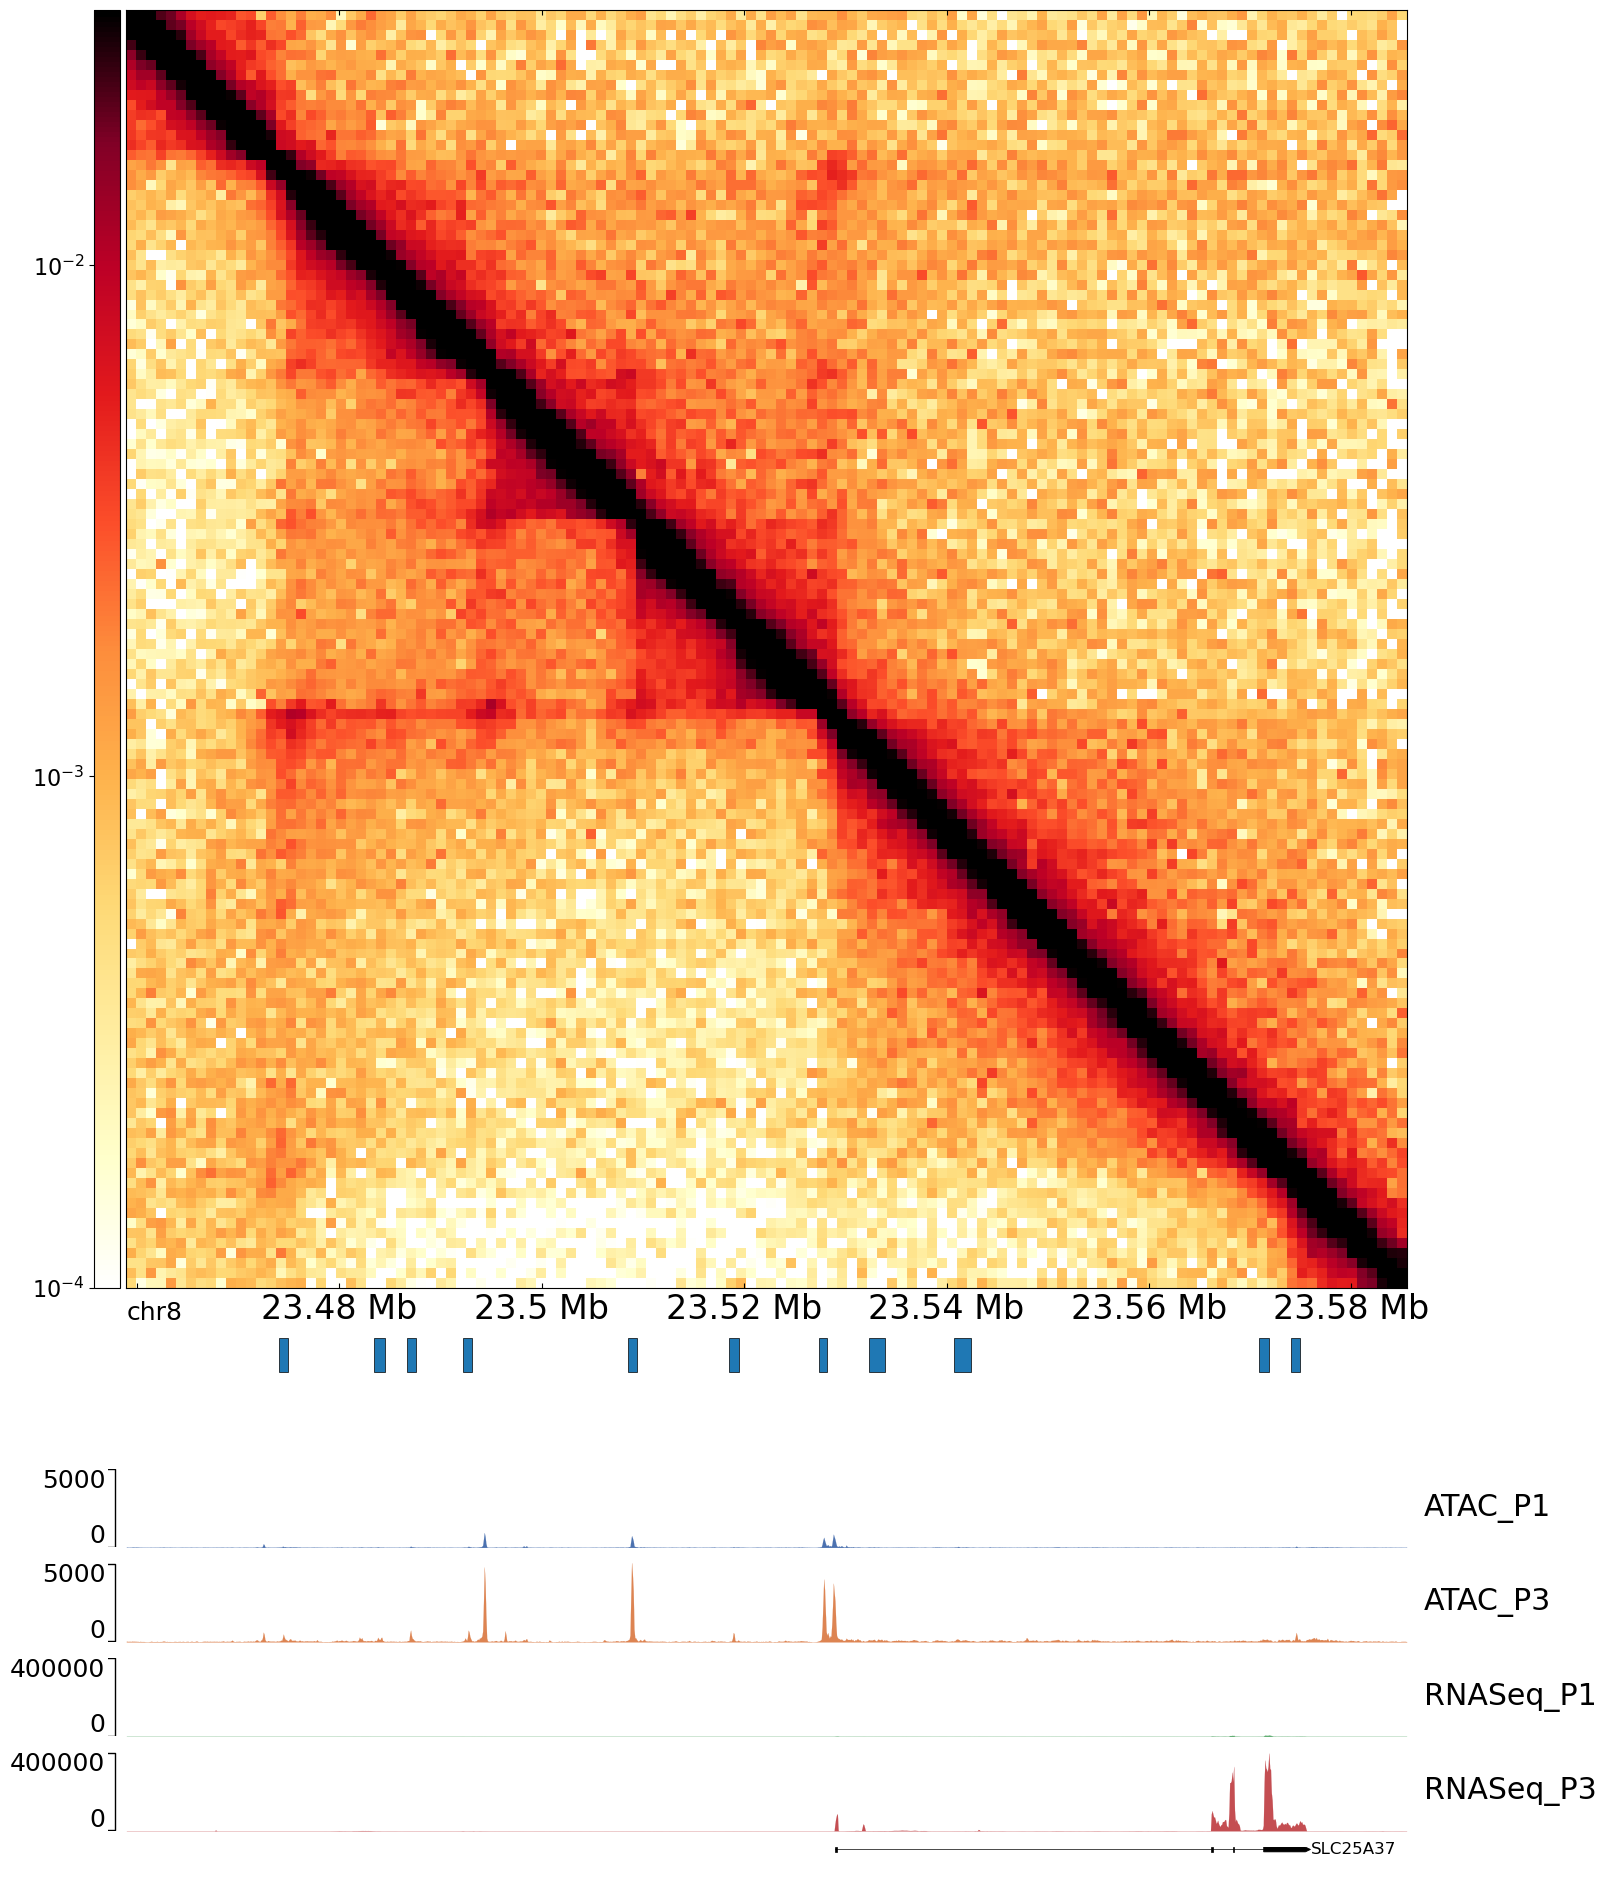

In [104]:
# Figure 2B, Slc25A37
savedir = os.path.join('/mnt/md0/varshini/Analysis/Blood/figs_v4/fig2')

if not os.path.exists(savedir):
    os.mkdir(savedir)
    
tf_acrs_name = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/erythroid_tracks/erythroid_tf_acrs_unique.bed'


GTF_PARAMS = [
     {"height":1},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    "gene_rows":3,
    "merge_transcripts":True,    
    "border_only":"true",
     "color":"#000000"
    }] 

BED_PARAMS = [{"height":1},
                      {"file": tf_acrs_name,
                      "max_labels":1,
                       "gene_rows":1,
                      "border_only":"true"}]

incl= ['ATAC_P1', 'ATAC_P3','RNASeq_P1', 'RNASeq_P3']

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-1.5,
                          "min_value":-4,
                          "fontsize":18}
resolution=1000
region_str = 'chr8:23,458,956-23,585,463'

chip_list = get_chip_list(include=incl, phase=1, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, plot_bed=True,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=False,
                            custom_valranges=(5000, 5000, 400000, 400000))
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, 'slc.svg'))
fig

chr11:16,066,449-16,709,591 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33071.50it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 7.9799999999999995,-0.08


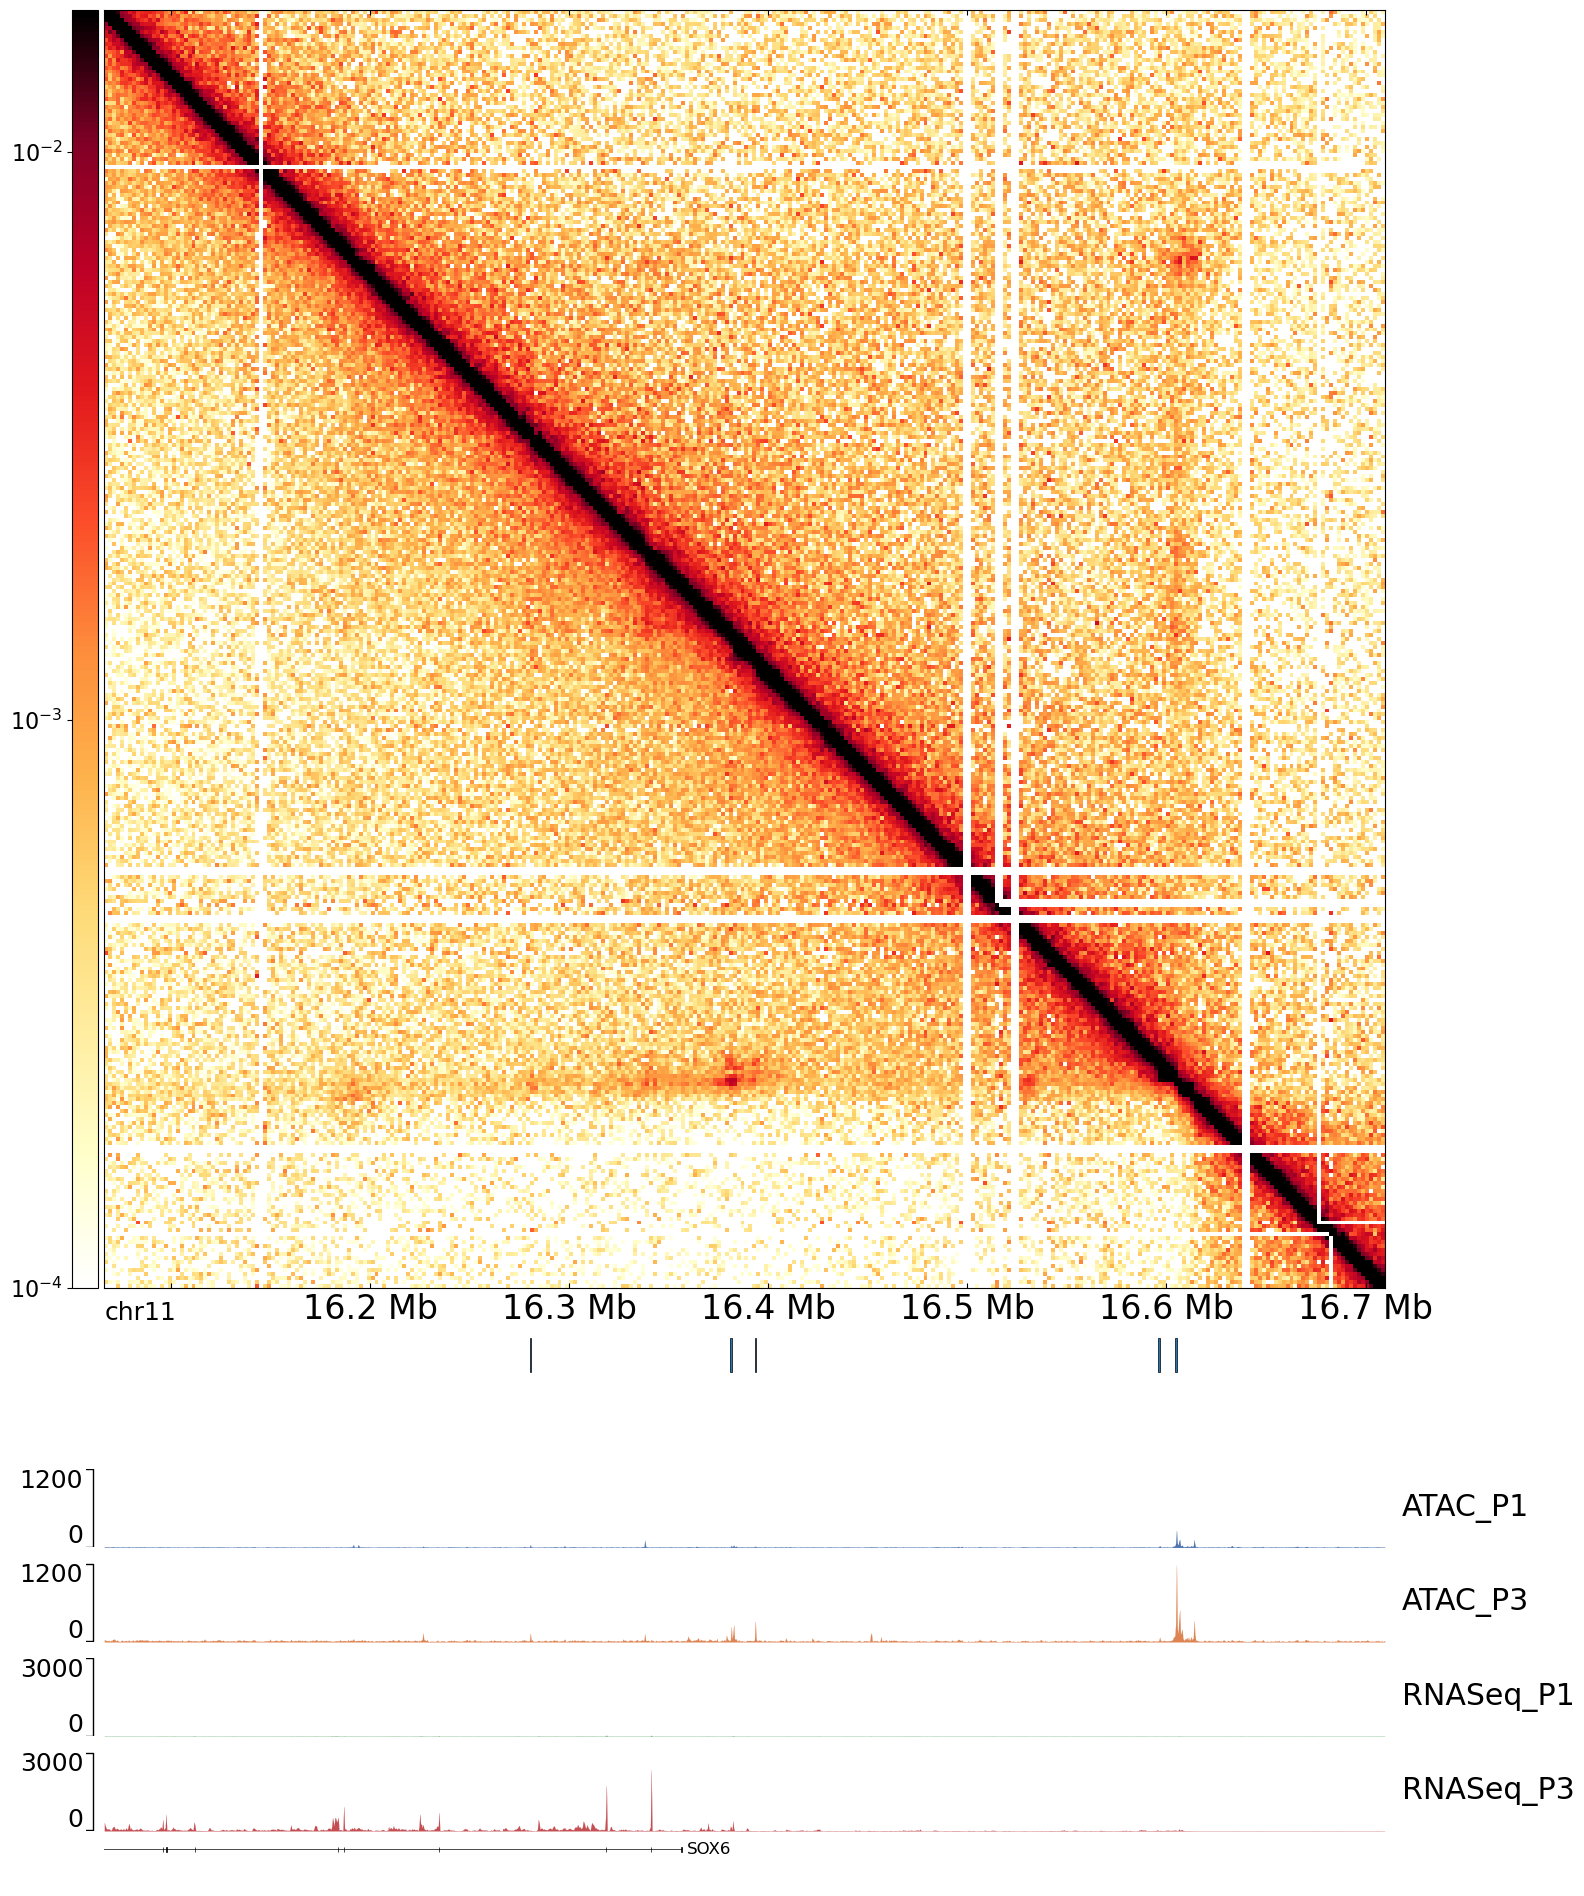

In [105]:
# Figure 2B, SOX6


GTF_PARAMS = [
     {"height":1},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    "gene_rows":3,
    "merge_transcripts":True,    
    "border_only":"true",
     "color":"#000000"
    }] 


incl= ['ATAC_P1', 'ATAC_P3','RNASeq_P1', 'RNASeq_P3']

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-1.75,
                          "min_value":-4,
                          "fontsize":18}
resolution=2000
region_str = 'chr11:16,066,449-16,709,591'

chip_list = get_chip_list(include=incl, phase=1, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, plot_bed=True,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=False,
                        custom_valranges=(1200, 1200, 3000, 3000))
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, 'sox6.svg'))
fig

In [107]:
mm="/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed"
top_match = pd.read_csv(mm, sep='\t').sort_values(by='triangle_score_P3', ascending=False)
top_match_loci = [utils.get_locus_from_coord(row, 200_000) for _, row in top_match.iloc[:350, :].iterrows()]

In [108]:
top_match_loci

['chr12:54105812-54505812',
 'chr17:44081815-44481815',
 'chr4:153307172-153707172',
 'chr11:1572708-1972708',
 'chr8:23308937-23708937',
 'chr3:195927558-196327558',
 'chr8:23318996-23718996',
 'chr20:40855800-41255800',
 'chr5:149712611-150112611',
 'chr18:74077553-74477553',
 'chr1:201876219-202276219',
 'chr2:85303772-85703772',
 'chr3:195938629-196338629',
 'chr1:21107802-21507802',
 'chr5:149730937-150130937',
 'chr2:112484041-112884041',
 'chr10:17468896-17868896',
 'chr6:36928641-37328641',
 'chr10:70096683-70496683',
 'chr6:13780050-14180050',
 'chrX:9847376-10247376',
 'chr14:30838818-31238818',
 'chr9:121151319-121551319',
 'chr10:102789173-103189173',
 'chr3:133683878-134083878',
 'chr3:130629169-131029169',
 'chr5:171948043-172348043',
 'chr14:64648114-65048114',
 'chr10:103439112-103839112',
 'chr14:54916555-55316555',
 'chr15:74220478-74620478',
 'chr16:75104614-75504614',
 'chr10:95332206-95732206',
 'chr18:57888176-58288176',
 'chr1:153688754-154088754',
 'chr8:1005641

In [129]:
tf_acrs_name = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/erythroid_tracks/erythroid_tf_acrs_unique.bed'
ctcf_stranded_bed = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/merged_CTCF_P123_strand.bed'
resolution=2000

BED_PARAMS = [{"height":1},
                      {"file": tf_acrs_name,
                      "max_labels":1,
                       "gene_rows":1,
                      "border_only":"true"}]

incl= ['H3K27ac_P2','H3K4me1_P2', 'CTCF_P2','CTCF_P3','RNASeq_P3']


MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                         "max_value":-1.25,
                          "min_value":-4.50,
                         "fontsize":18}


GTF_PARAMS = [
     {"height":4},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    #"gene_rows":1,
    "merge_transcripts":True,       
    "border_only":"true",
     "color":"#000000"
    }] 


In [130]:
regions_mm = {
        'match_2d_1':'chr12:54105812-54505812',
        'match_2d_2':'chr17:44081815-44481815',
        'match_2d_3':'chr11:33744908-34144908',
        'match_2d_4': 'chr1:153688754-154088754',
        'match_3a':'chr2:85303772-85703772',
        'match_4a': 'chr14:64648114-65048114'
}

chr12:54105812-54505812 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33287.87it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 5.68,-0.08


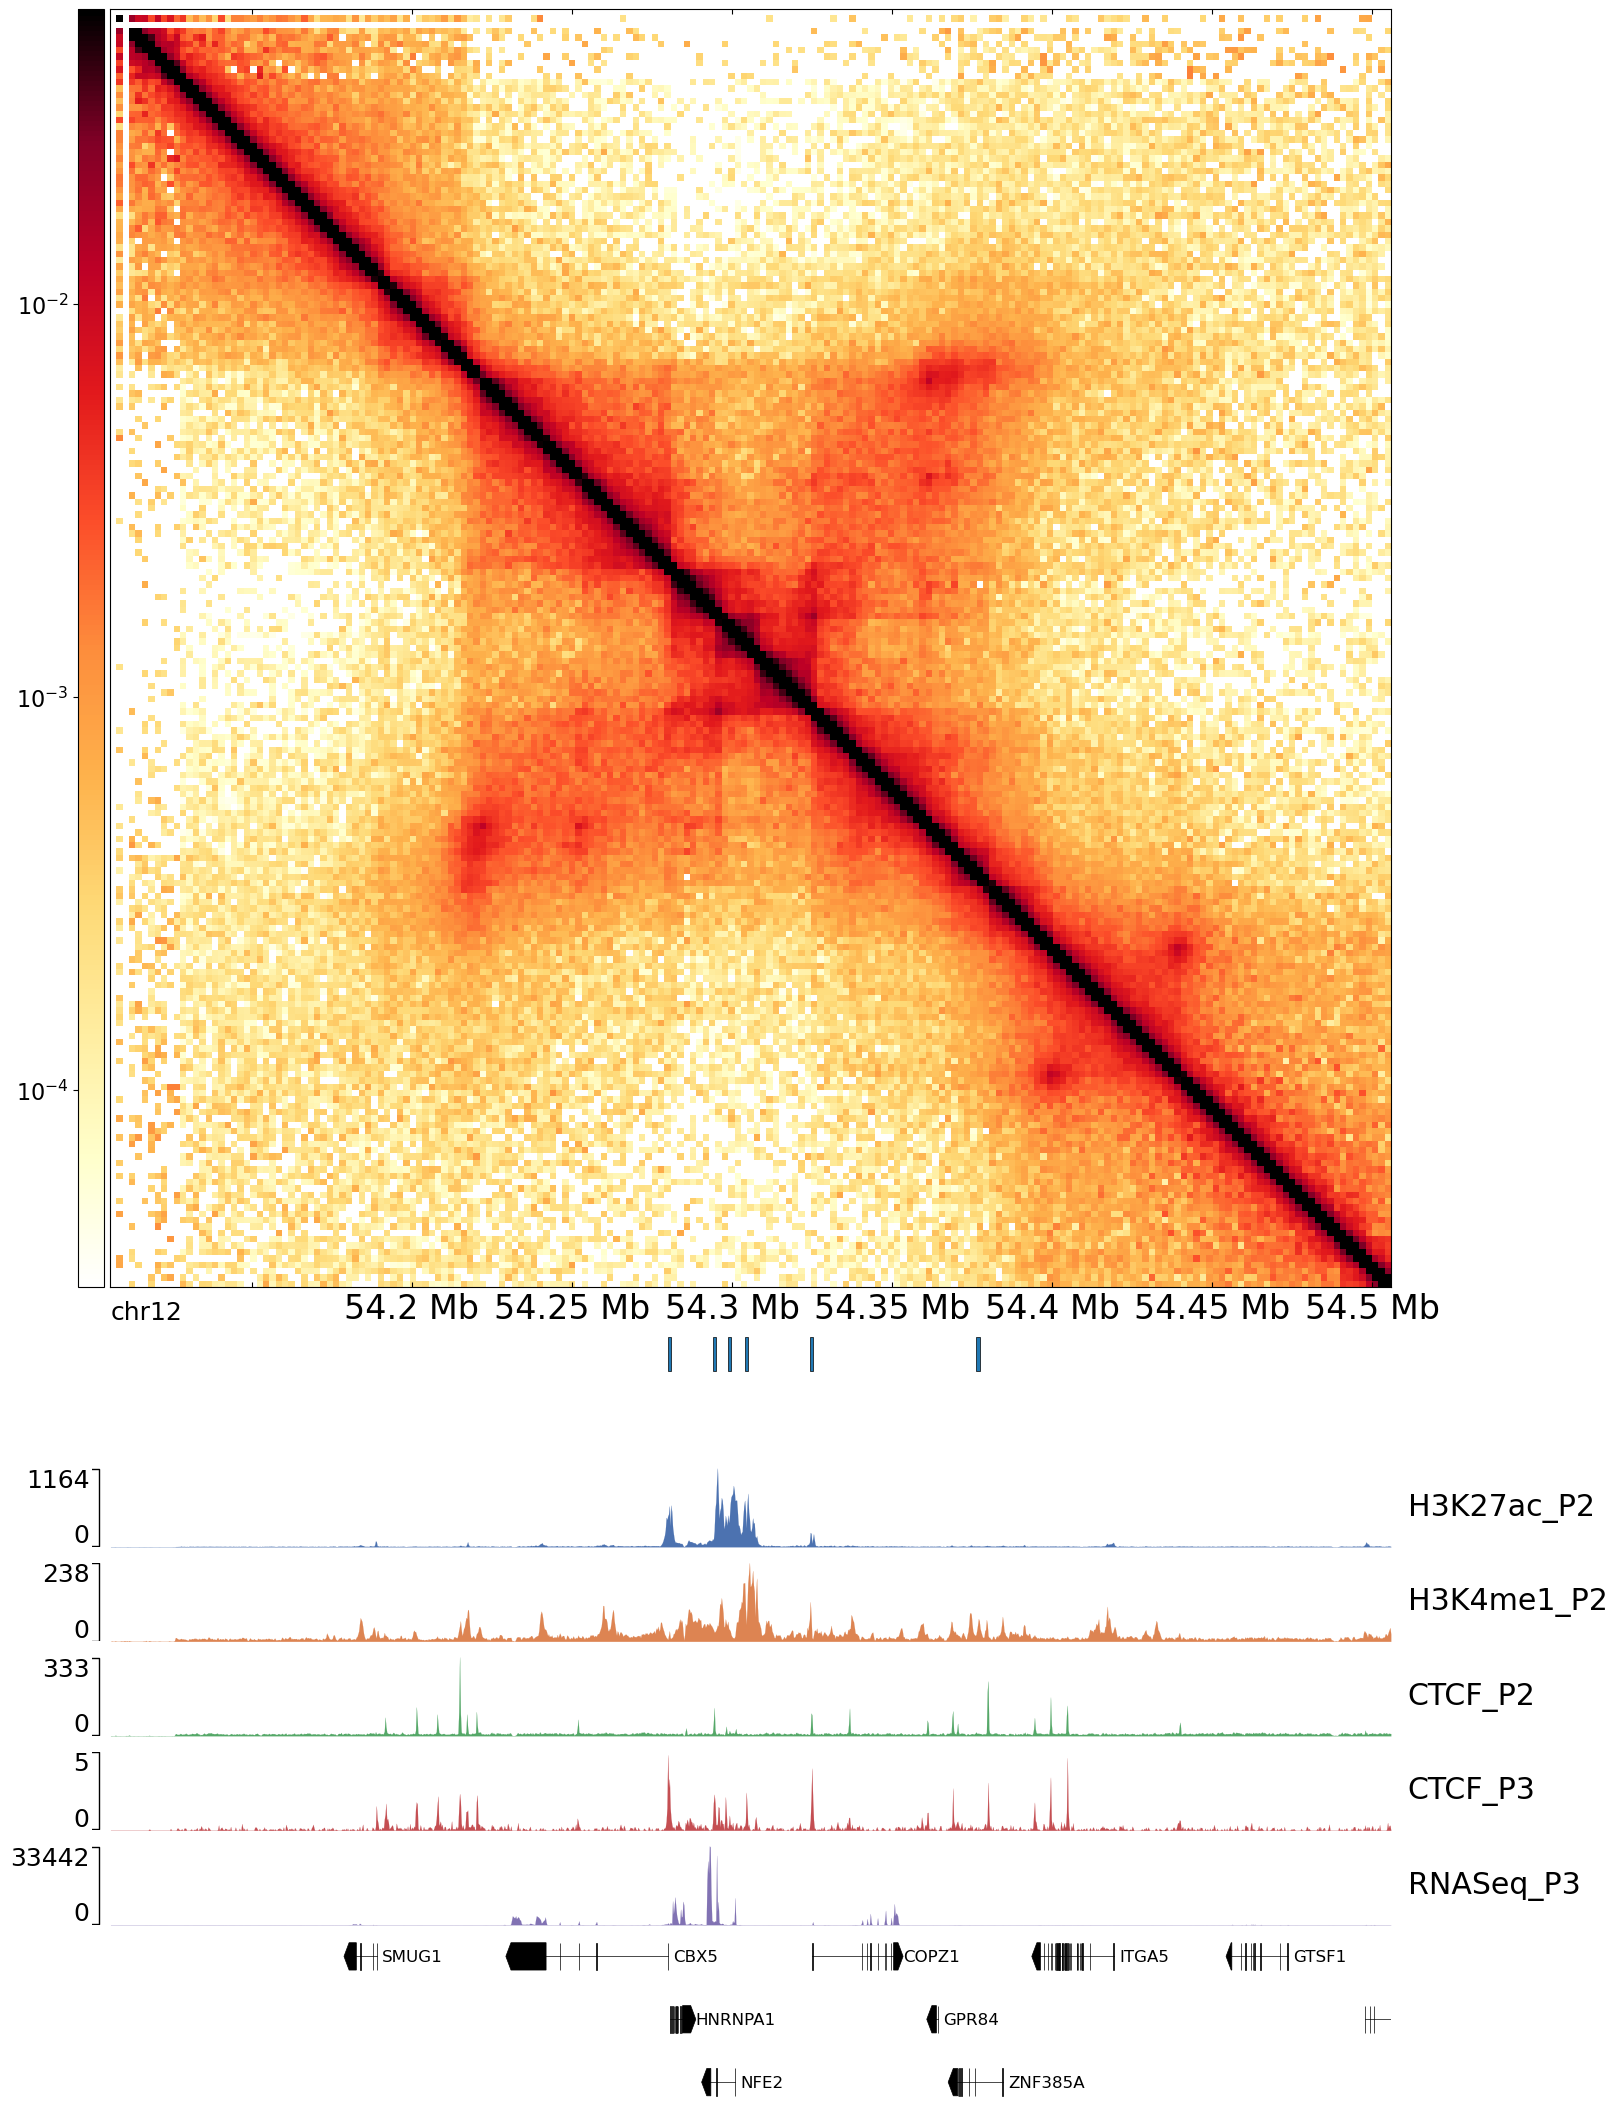

In [131]:
region_str = regions_mm['match_2d_1']
chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True, plot_bed=True,
                            plot_genes=True)
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "match_2d_1.svg"))

fig

chr17:44081815-44481815 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 29354.42it/s]


bar is on
32.45700000000001
37.2


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 7.9799999999999995,-0.08


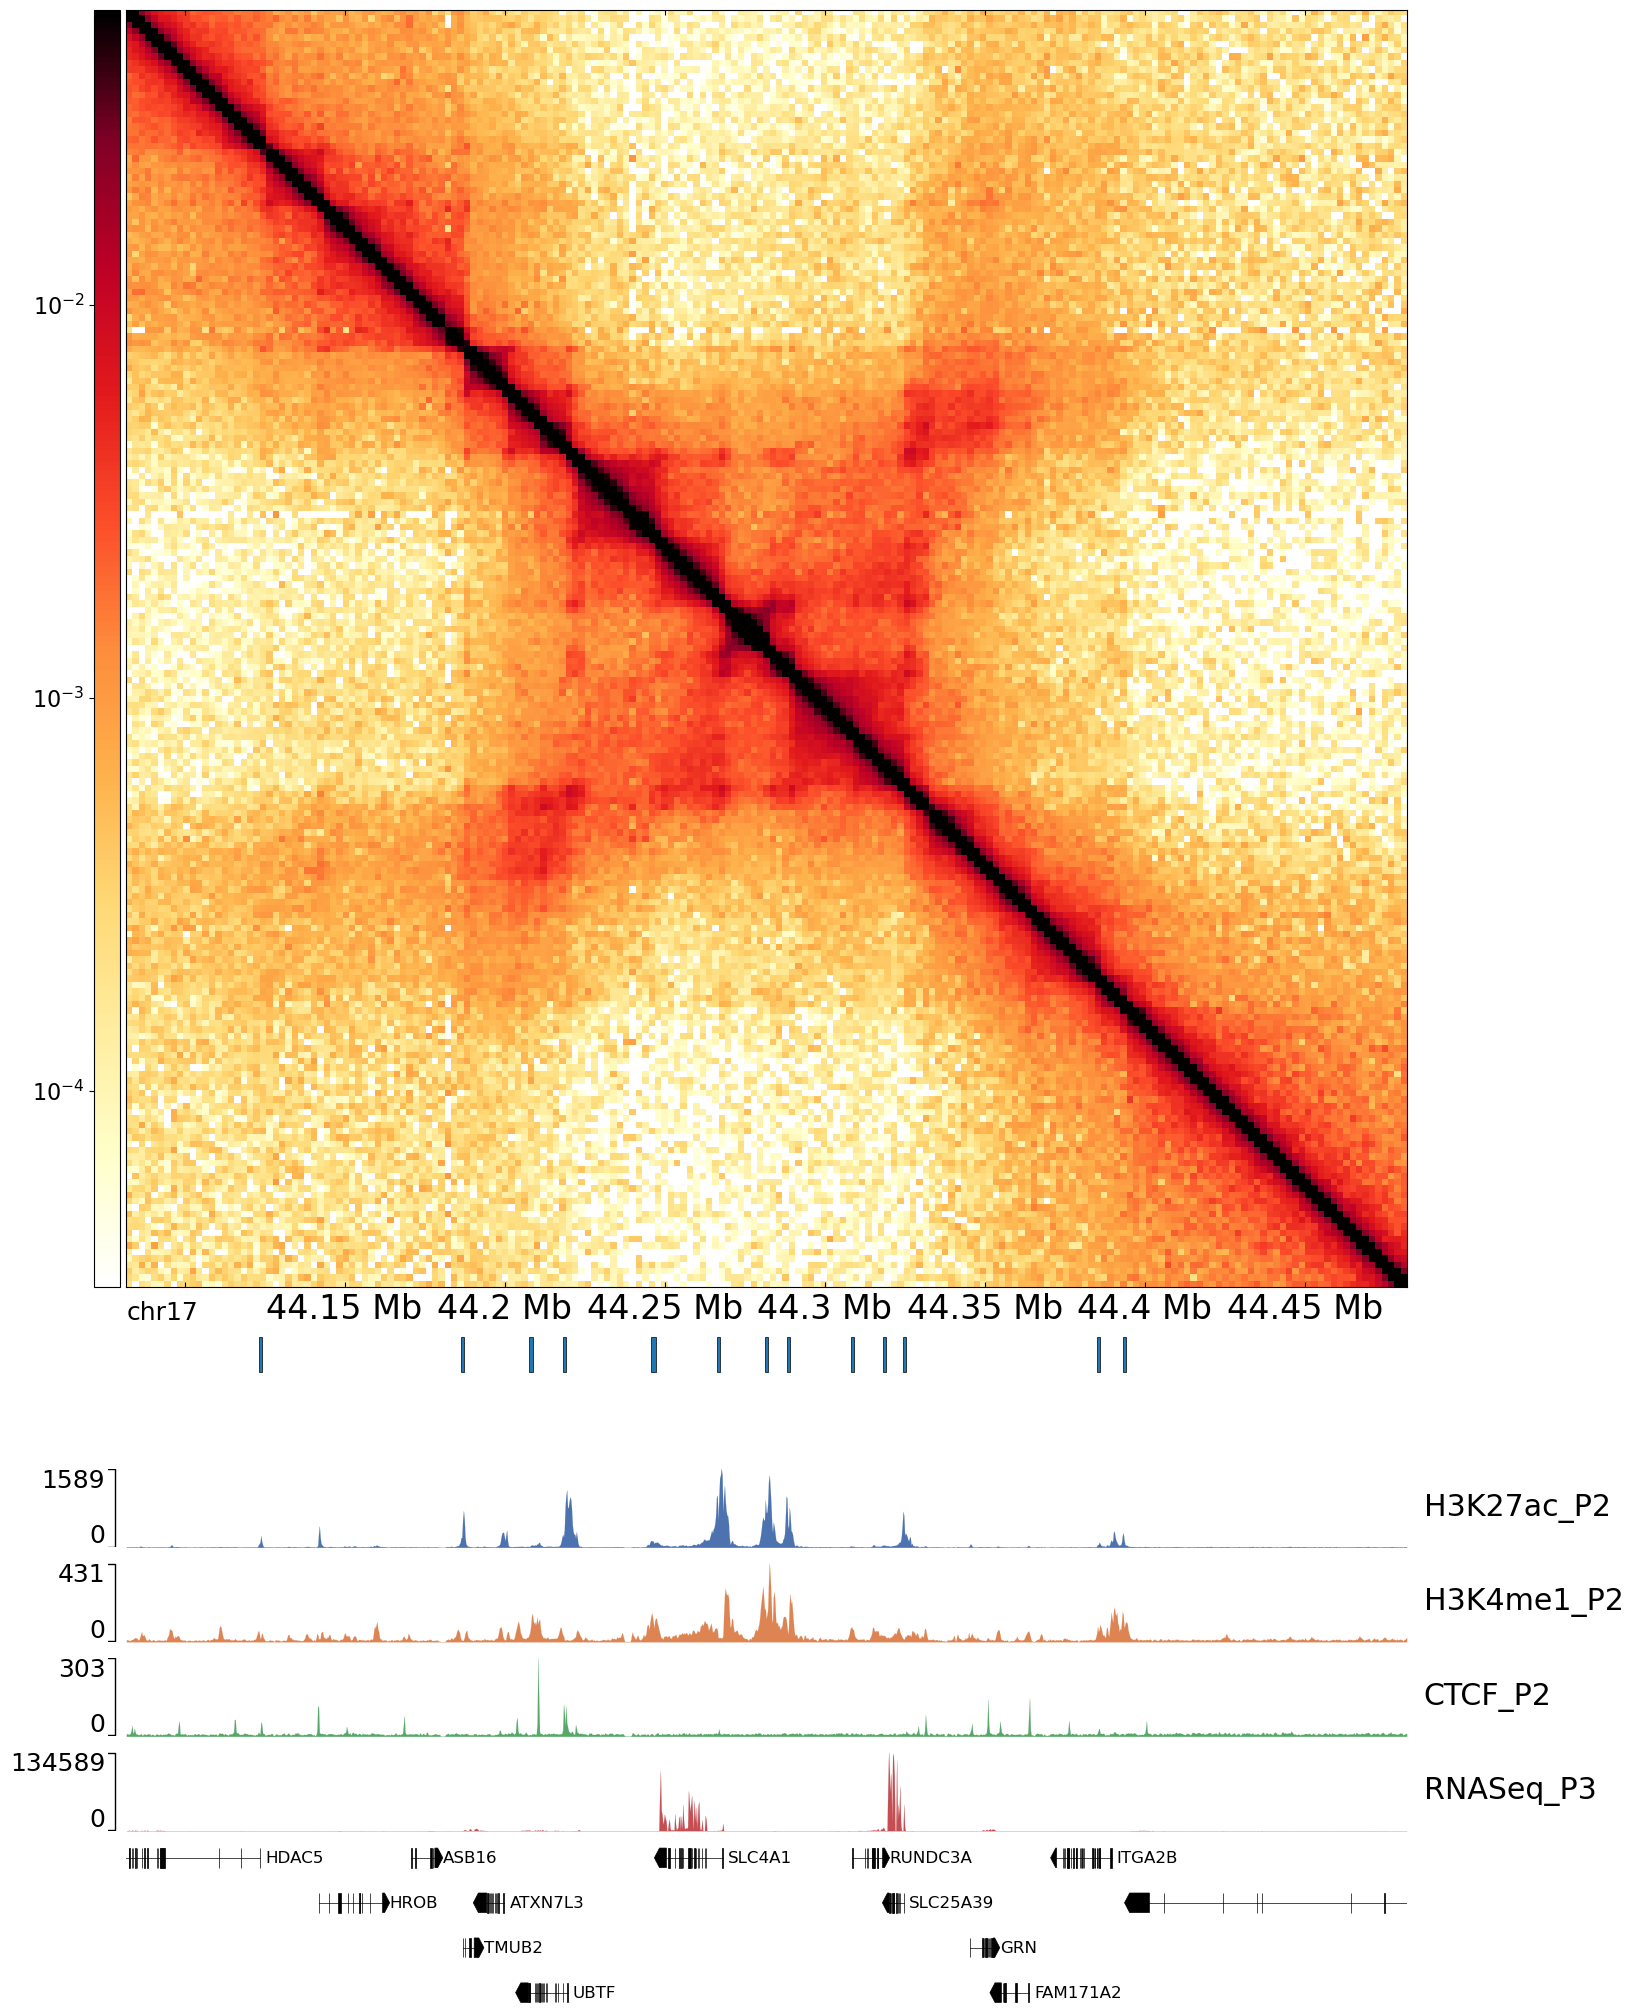

In [132]:
region_str = regions_mm['match_2d_2']

incl= ['H3K27ac_P2','H3K4me1_P2', 'CTCF_P2','RNASeq_P3']

chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True, plot_bed=True,
                            plot_genes=True)
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "match_2d_2.svg"))

fig

In [ ]:
region_str = 'chr11:33744908-34084908'

incl= ['H3K27ac_P2','H3K4me1_P2', 'CTCF_P2','RNASeq_P3']

chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True, plot_bed=True,
                            plot_genes=True)
fig = frame.plot(region_str)
#fig.savefig(os.path.join(savedir, "match_2d_3_zoom.svg"))

fig

chr11:33744908-34144908 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33843.19it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


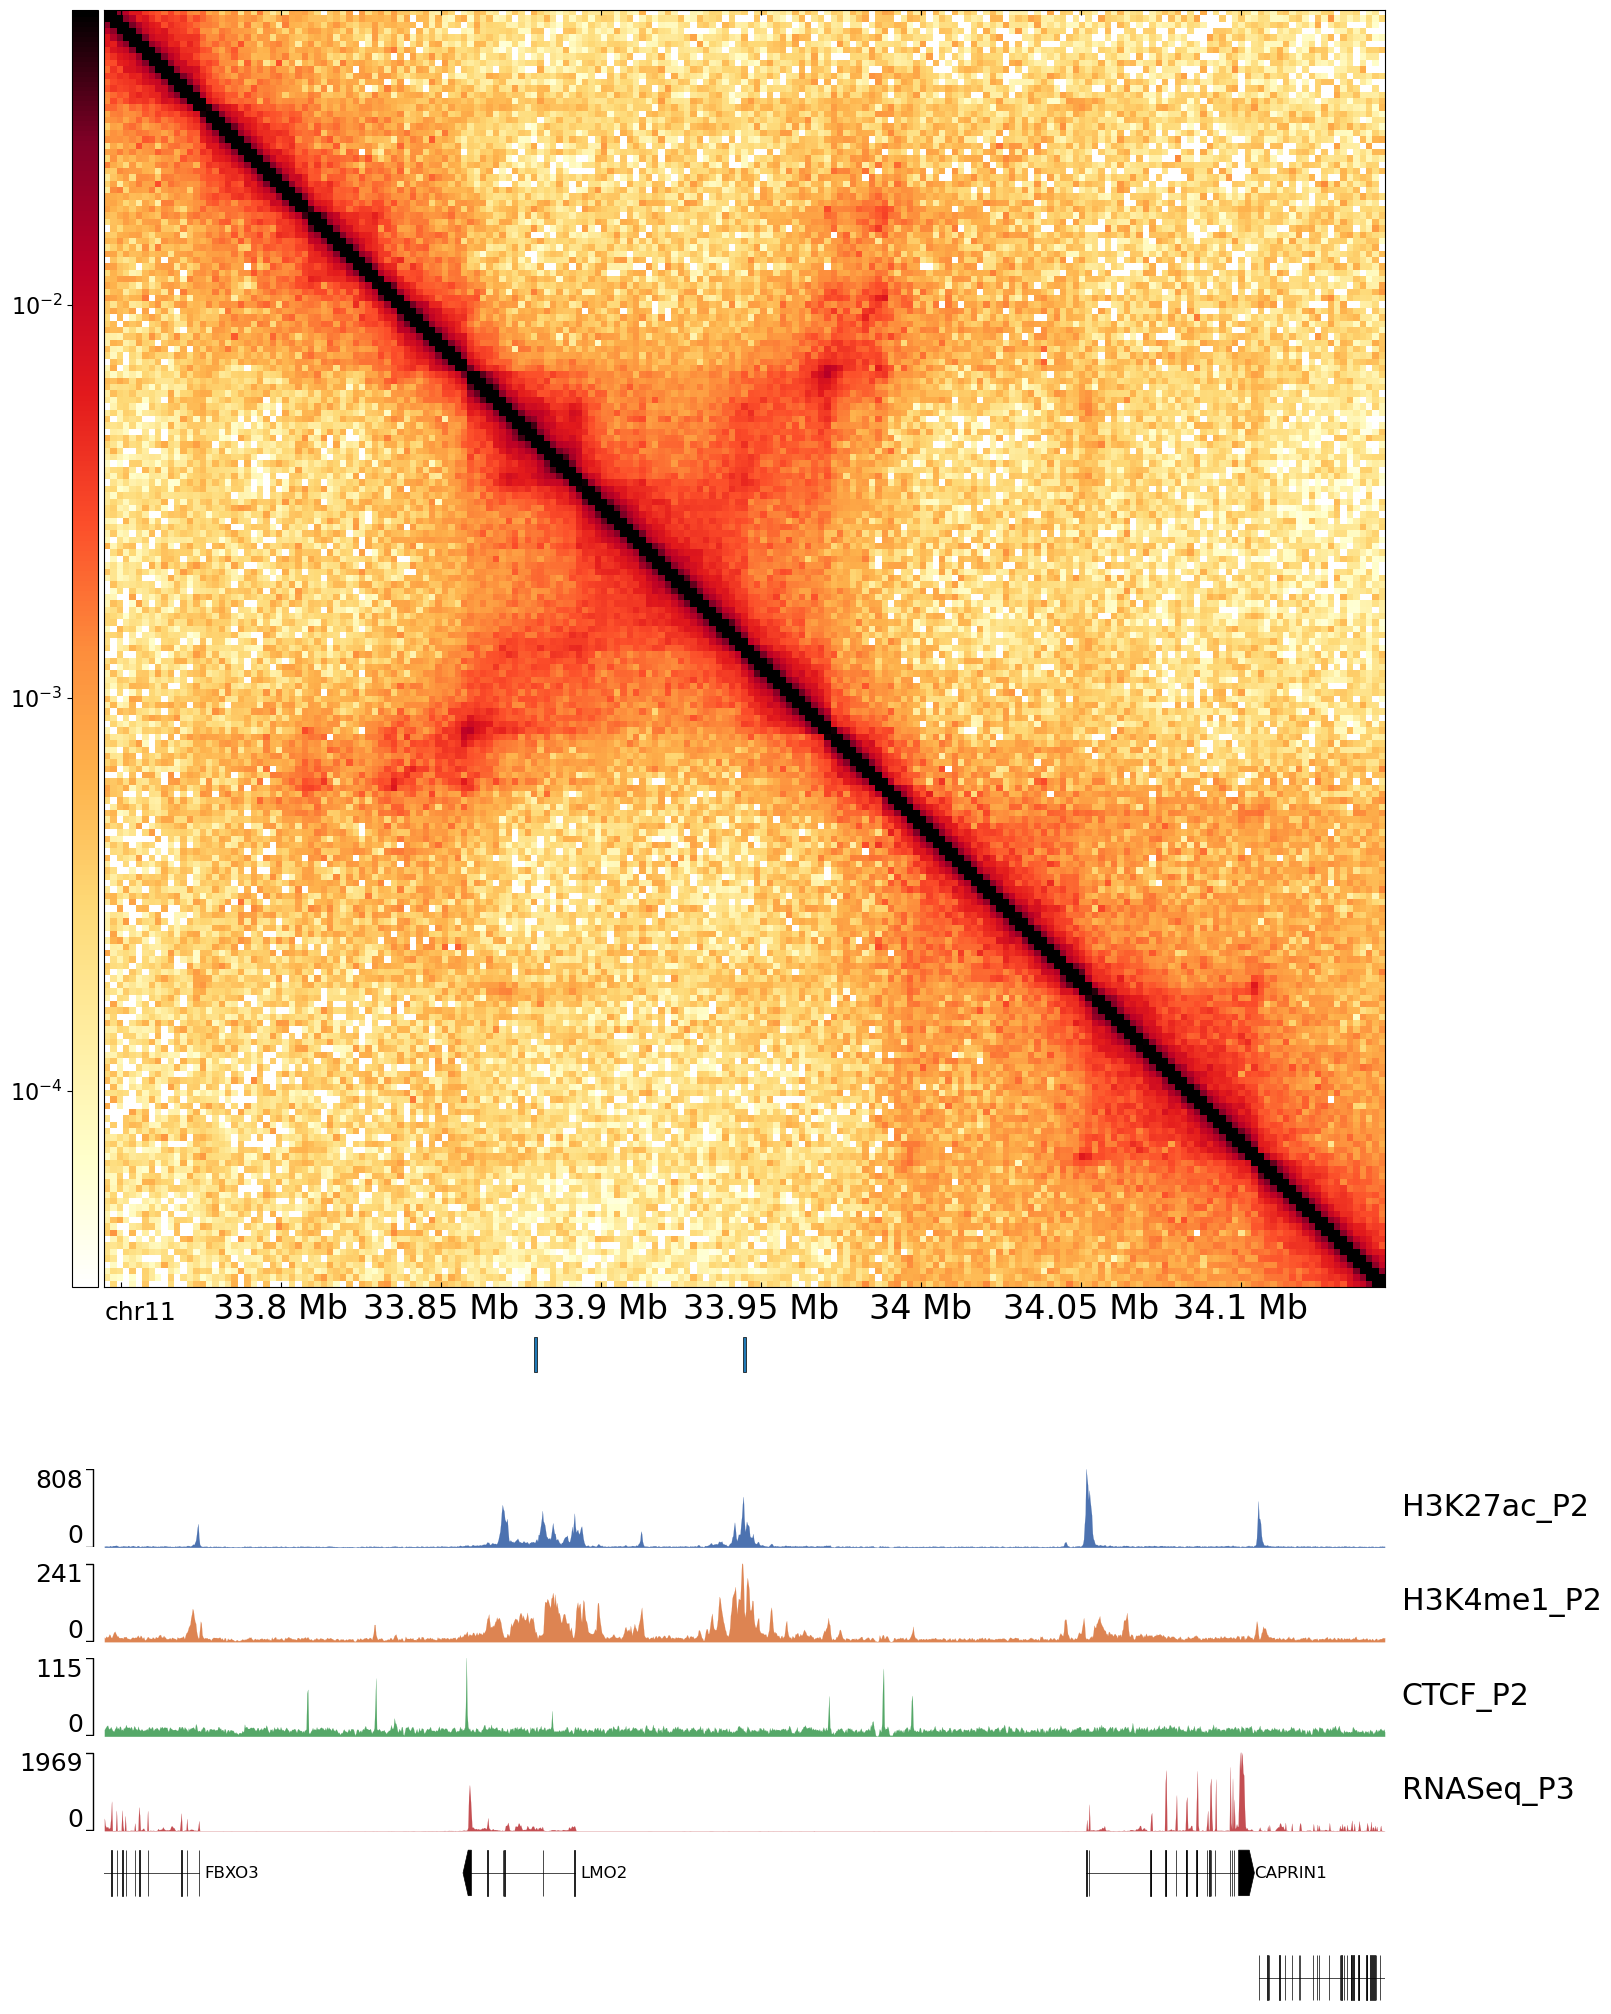

In [136]:
region_str = 'chr11:33744908-34144908'

incl= ['H3K27ac_P2','H3K4me1_P2', 'CTCF_P2','RNASeq_P3']

chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True, plot_bed=True,
                            plot_genes=True)
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "match_2d_3.svg"))

fig

chr1:153688754-154088754 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 34043.66it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 12.58,-0.08


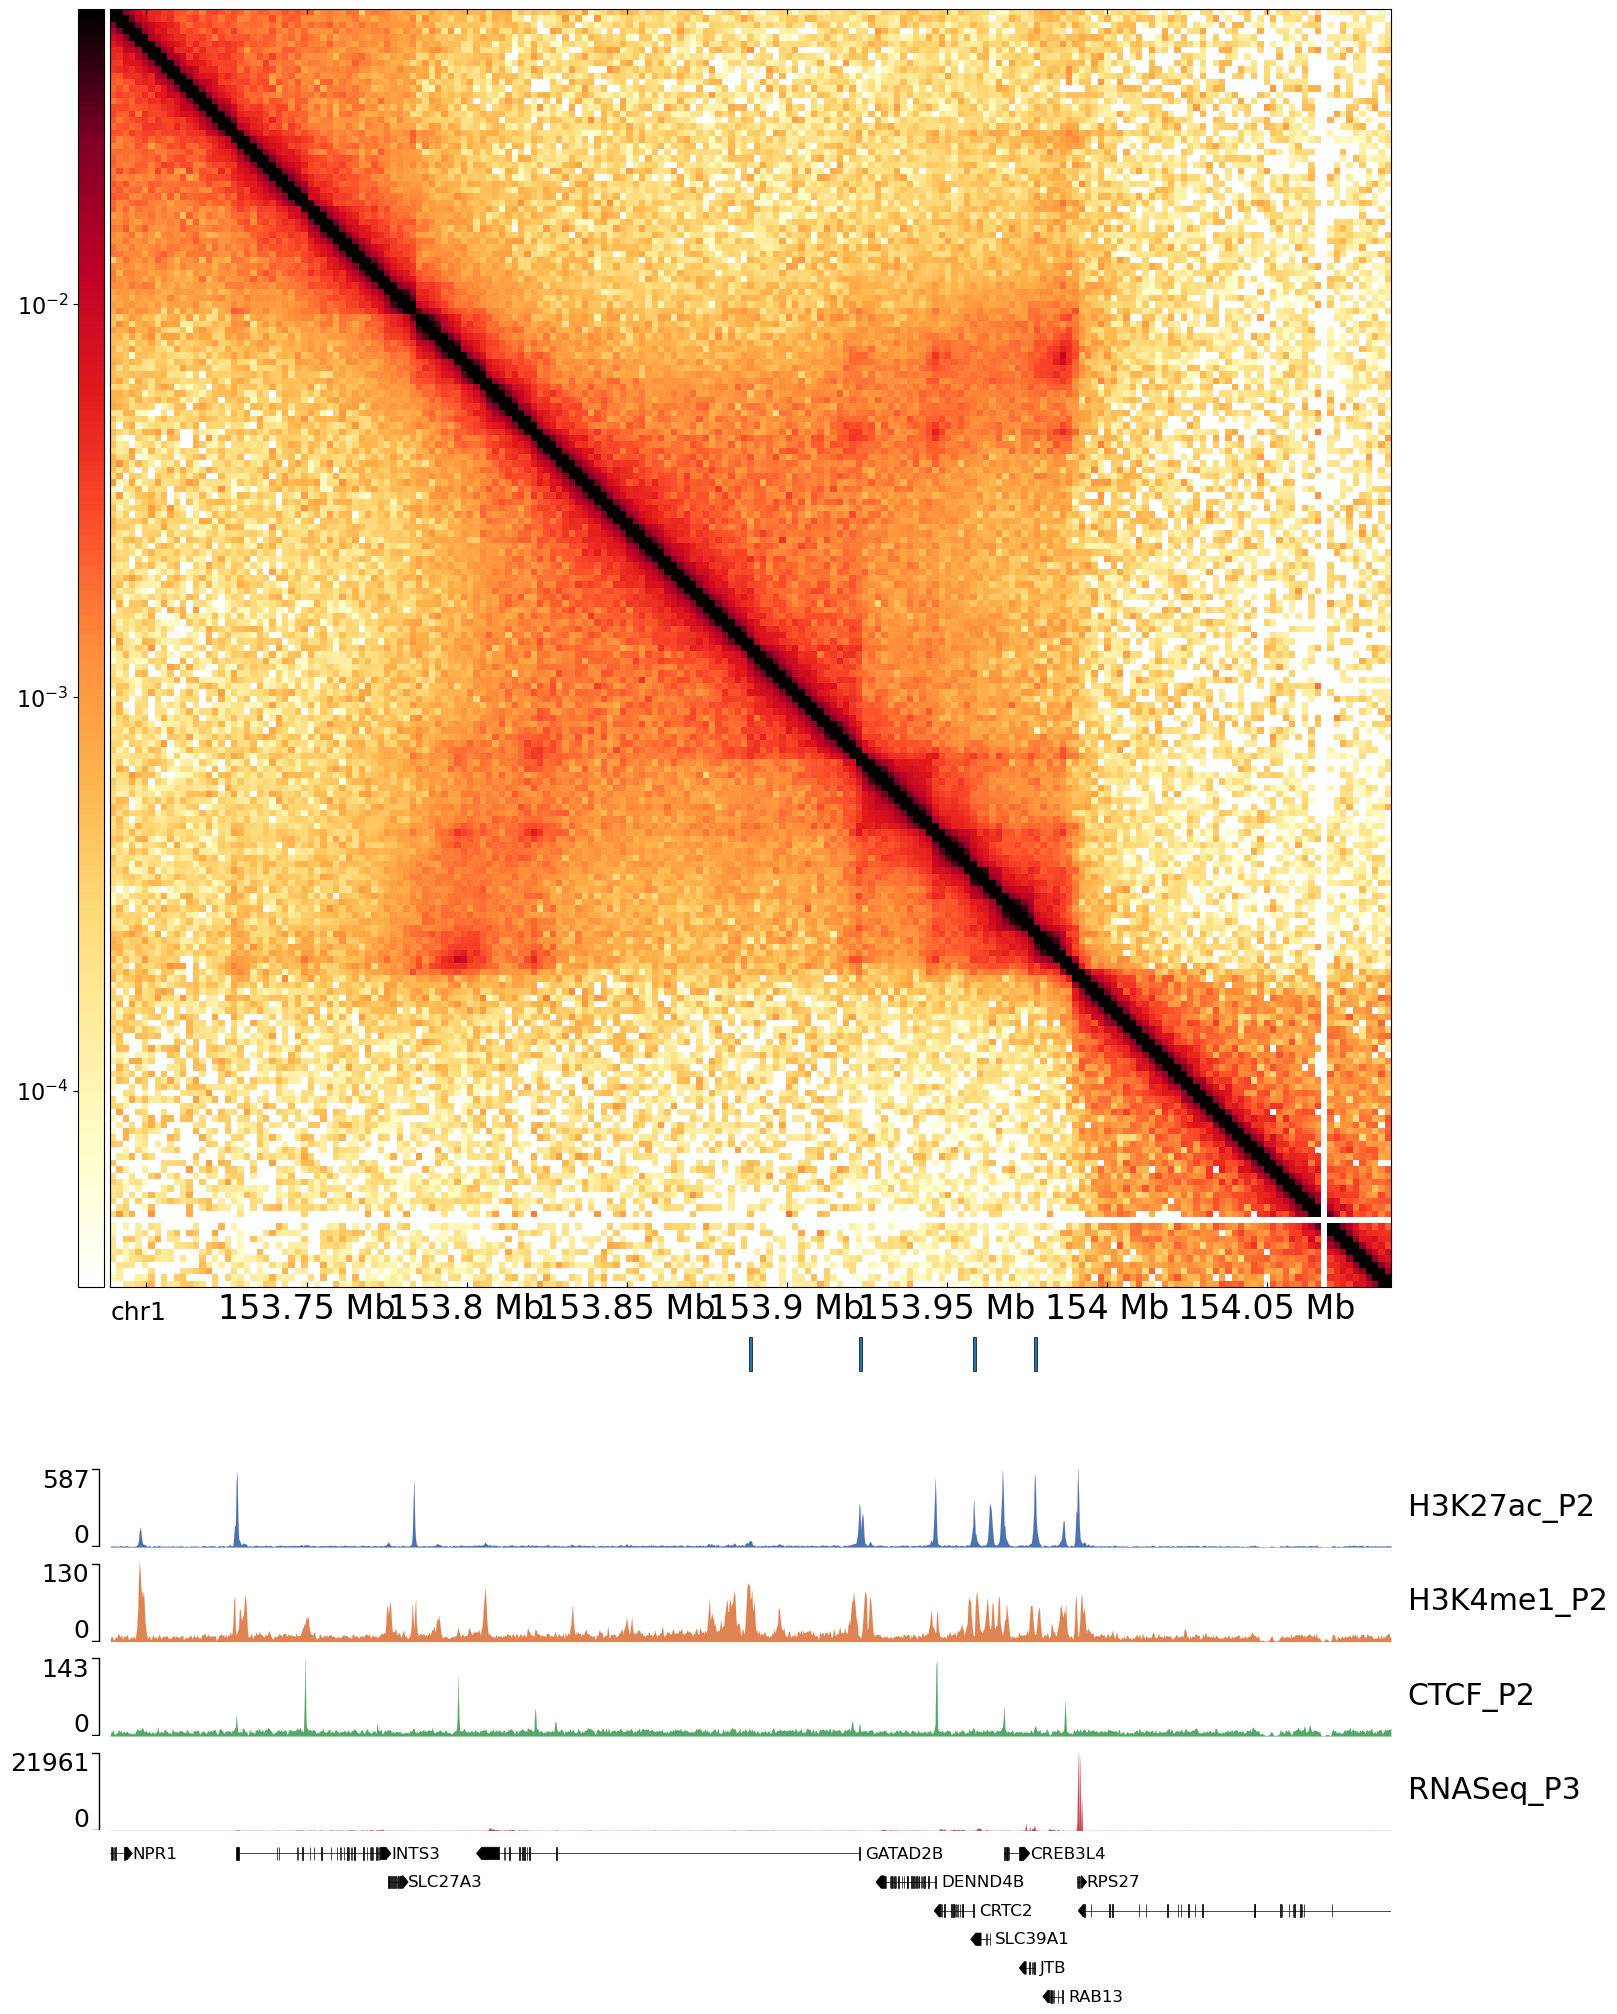

In [137]:
region_str = 'chr1:153688754-154088754'
resolution = 2000
incl= ['H3K27ac_P2','H3K4me1_P2', 'CTCF_P2','RNASeq_P3']

chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True, plot_bed=True,
                            plot_genes=True)
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "match_2d_4.svg"))

fig

## Figure 3

In [39]:
region_str = regions_mm['match_3a']

chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True, plot_bed=True,
                            plot_genes=True)
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "match_3a.svg"))

chr2:85303772-85703772 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 32355.23it/s]
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


You've reached the modified Cool class!
[-4 -3 -2]


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 10.28,-0.08


In [40]:
MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                         "max_value":0.01,
                          "min_value":0.00,
                         "fontsize":18}
resolution=3200

region_str = regions_mm['match_4a']

chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, variant_track_height=5,
                         file_bottom = uc_filenames[2], cmap_chip="deep", autoscale=True, plot_bed=True,
                            plot_genes=True)
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, "match_4a.svg"))

chr14:64648114-65048114 3200 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 32621.69it/s]


You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 5.68,-0.08
